# Л1 — Підготовка даних

Велика частина роботи в Data Science — збір і підготовка даних. Саме тут виникає багато неочікуваних проблем і пасток.

Ноутбук нижче базово показує, як працювати з даними й готувати їх. Він не охоплює всіх можливих сценаріїв, а приклади в ньому часом сильно спрощені. Проте він дасть розуміння, де шукати помилки і як з ними боротися. Більше туторіалів — у [Kaggle Learn](https://www.kaggle.com/learn), зокрема [Data Cleaning](https://www.kaggle.com/learn/data-cleaning).

Базовий алгоритм підготовки даних може виглядати так (у дужках — кроки цього ноутбука):

- зчитування даних і початкове дослідження (1);
- дослідження структури й особливостей даних, зміна типів (2);
- об'єднання даних з різних джерел (3–4);
- робота з пропущеними й зламаними значеннями: drop, fill тощо (5, 7, 8);
- пошук outliers: drop, clip тощо (6);
- пошук зайвих і бракуючих колонок (9).

І головне: з кожною дією треба бути обережним. Outliers можуть бути реальними даними, які логічно пояснюються і які не можна видаляти. А пропущені значення можуть щось означати й бути корисними. Обидва випадки є в цій роботі.

Далі бувають кроки, специфічні для певних моделей чи алгоритмів:

- scaling: normalization, standardization тощо;
- обробка категорійних колонок: one-hot encoding тощо;
- dimensionality reduction.

Тут вони не розглядаються, частину з них побачите в Л2 і Л3.

Шаблон веде покроково: у кожному кроці — навіщо він і що зробити, у клітинці з `TODO` — ваш код. Опис даних і таблиця недоліків — у `README.md`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Завантаження даних

На цьому етапі важливо впевнитися, що файли завантажено правильно, і подивитися, що взагалі всередині. Можуть допомогти `df.head()`, `df.tail()`, `df.shape` і `df.dtypes`.

Що ви маєте зрозуміти?

- Чи зчиталися дані взагалі?
- Чи правильно розпарсилися рядки, колонки й значення?
- Які типи в колонок?
- Які приблизно значення?
- Скільки рядків і колонок?

In [3]:
# TODO: завантажте meters.parquet і registry.csv свого варіанта з папки variants/<варіант>/
# df_meters = pd.read_parquet(...)
# df_registry = pd.read_csv(...)
# ...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data_path = "/content/drive/MyDrive/IAD_Lab1"


df_meters = pd.read_parquet(f"{data_path}/meters.parquet")
df_registry = pd.read_csv(f"{data_path}/registry.csv")

print("df_meters shape:", df_meters.shape)
print("df_registry shape:", df_registry.shape)
display(df_meters.head(3))
display(df_registry.head(3))

df_meters shape: (525556, 4)
df_registry shape: (800, 7)


,meter_id,ts,consumption_kwh,record_ts
0,UA101530,2026-01-05 00:00:00,0.3510,2026-01-05 00:10:20
1,UA101530,2026-01-05 01:00:00,0.3929,2026-01-05 01:14:45
2,UA101530,2026-01-05 02:00:00,0.3552,2026-01-05 02:03:13


,meter_id,customer_type,tariff,electric_heating,connection_year,years_connected,district
0,UA101530,household,dual_zone,0,2020,6,Obolon
1,UA101567,industrial,single,0,2000,26,Sviatoshyn
2,UA104444,household,dual_zone,1,1995,30,darnytsia


## 2. Звірка з описом

Іноді бізнес надає опис ідеальних даних, але реальні дані часто з ним не збігаються. Тому спершу подивіться, чи ваші дані відповідають опису в `README.md`. Може допомогти `df.describe()`.

Перевірте (але поки не виправляйте):

- типи колонок: якщо число прочиталося як текст, частина операцій спрацює неправильно;
- скільки рядків мають `customer_type`, `tariff` чи `electric_heating`, яких немає в описі;
- скільки рядків мають `ts`, `connection_year` чи `years_connected` поза межами з опису;
- скільки різних лічильників у кожному файлі — мають бути по 800.

Можуть допомогти `isin`, `between` і `nunique`.

Недоліки з таблиці в `README.md` перевірятимете далі, кожен у своєму кроці. Межі споживання залежать від типу абонента, а тип є лише в реєстрі, тому їх перевірите після об'єднання, на кроці 6.

In [4]:
# TODO: звірте дані з описом
print("Унікальних лічильників meters:", df_meters["meter_id"].nunique())
print("Унікальних лічильників registry:", df_registry["meter_id"].nunique())

valid_types = ["household", "small_business", "industrial"]
valid_tariffs = ["single", "dual_zone"]
valid_districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]

print("Невідомих customer_type:", (~df_registry["customer_type"].isin(valid_types)).sum())
print("Невідомих tariff:", (~df_registry["tariff"].isin(valid_tariffs)).sum())
print("electric_heating не в [0, 1]:", (~df_registry["electric_heating"].isin([0, 1])).sum())

# Перевірка меж числових полів
print("ts поза межами:", (~df_meters["ts"].between("2026-01-05 00:00", "2026-02-01 23:00")).sum())
print("connection_year поза [1985, 2024]:", (~df_registry["connection_year"].between(1985, 2024)).sum())
print("years_connected поза [1, 41]:", (~df_registry["years_connected"].between(1, 41)).sum())

Унікальних лічильників meters: 800
Унікальних лічильників registry: 800
Невідомих customer_type: 0
Невідомих tariff: 0
electric_heating не в [0, 1]: 0
ts поза межами: 0
connection_year поза [1985, 2024]: 0
years_connected поза [1, 41]: 0


## 3. Реєстр: номери й райони (D-E, D-F)

Дані зберігаються в різних системах, тому формат ідентифікатора може не збігатися: `" UA123456"` для pandas — інший номер, ніж `UA123456`. Наївний join призведе до того, що частина даних втратиться. Так само `podil` і `Podil` — різні райони, і будь-який підрахунок по районах буде хибним.

Для D-E і D-F виведіть, скільки рядків реєстру зіпсовано, і виправте їх так, як сказано в таблиці недоліків. Можуть допомогти `str.fullmatch(r"UA\d{6}")`, `isin`, `str.strip()`, `str.lstrip("0")` і `str.capitalize()`.

In [5]:
# TODO: D-E — виведіть кількість зіпсованих номерів і виправте meter_id у реєстрі

# TODO: D-F — виведіть кількість рядків, де district написано не як в описі, і виправте
# D-E: Зіпсовані номери
invalid_ids_mask = ~df_registry["meter_id"].str.fullmatch(r"UA\d{6}")
de_count = invalid_ids_mask.sum()
print(f"D-E: зіпсованих номерів у реєстрі = {de_count}")

# Виправлення: видаляємо зайві пробіли та нулі перед UA
df_registry["meter_id"] = (
    df_registry["meter_id"]
    .str.strip()
    .str.lstrip("0")
)
assert df_registry["meter_id"].str.fullmatch(r"UA\d{6}").all(), "D-E не повністю виправлено!"

# D-F: Різне написання районів
invalid_districts_mask = ~df_registry["district"].isin(valid_districts)
df_count = invalid_districts_mask.sum()
print(f"D-F: рядків з некоректним district = {df_count}")

# Виправлення: зведення до капіталізованого формату (Podil, Solomianka тощо)
df_registry["district"] = df_registry["district"].str.strip().str.capitalize()
assert df_registry["district"].isin(valid_districts).all(), "D-F не повністю виправлено!"

D-E: зіпсованих номерів у реєстрі = 96
D-F: рядків з некоректним district = 80


## 4. Об'єднання

Тепер погодинні дані можна об'єднати з реєстром за `meter_id` (join, у pandas — `merge`). pandas не попереджає, коли рядок не знайшов пари, тому якість об'єднання треба перевірити самому.

Об'єднану таблицю назвіть `df`, з нею працюватимете далі. Перевірте й виведіть:

- кількість рядків до і після об'єднання — вона не має змінитися;
- кількість рядків без атрибутів абонента (пропуск у `customer_type`) — має бути 0.

Може допомогти `merge(..., how="left", validate="m:1")`: `validate` ще й перевірить, що кожному лічильнику відповідає один рядок реєстру.

In [ ]:
# TODO: об'єднайте погодинні дані з реєстром і перевірте об'єднання
# Об'єднуємо погодинні дані з реєстром
df = df_meters.merge(df_registry, on="meter_id", how="left", validate="m:1")

print(f"Рядків до: {len(df_meters)}, рядків після: {len(df)}")
print(f"Рядків без customer_type: {df['customer_type'].isna().sum()}")

assert len(df) == len(df_meters), "Кількість рядків змінилася під час merge!"
assert df["customer_type"].notna().all(), "Знайдено пропуски після merge!"

Рядків до: 525556, рядків після: 525556
Рядків без customer_type: 0


## 5. Повторні відправки (D-C)

Повторна відправка — та сама година того самого лічильника ще раз, іноді з уточненим значенням. Якщо лишити обидва записи, споживання за цю годину подвоїться. Лишаємо найпізніший за `record_ts` запис як найсвіжіший.

Виведіть кількість рядків і кількість різних пар `meter_id` і `ts`, потім зніміть повтори. Можуть допомогти `duplicated(["meter_id", "ts"])`, `sort_values("record_ts")` і `drop_duplicates(["meter_id", "ts"], keep="last")`.

In [ ]:
# TODO: D-C — виведіть обидві кількості й лиште для кожної пари найпізніший запис
n_rows_before = len(df)
n_unique_pairs = df.groupby(["meter_id", "ts"]).ngroups
dc_count = n_rows_before - n_unique_pairs

print(f"D-C: усього рядків = {n_rows_before}")
print(f"D-C: унікальних пар (meter_id, ts) = {n_unique_pairs}")
print(f"D-C: зайвих повторних відправок = {dc_count}")

# Лишаємо останній запис за record_ts
df = (
    df.sort_values("record_ts")
    .drop_duplicates(subset=["meter_id", "ts"], keep="last")
    .reset_index(drop=True)
)
print(f"Рядків після зняття повторів: {len(df)}")

D-C: усього рядків = 525556
D-C: унікальних пар (meter_id, ts) = 515359
D-C: зайвих повторних відправок = 10197
Рядків після зняття повторів: 515359


## 6. Одиниці виміру (D-D)

Значення у Вт·год схожі на викиди, але це не шум, а помилка одиниць. Якщо їх видалити, зникнуть цілі абоненти.

1. Для кожного лічильника порахуйте відношення його медіани `consumption_kwh` до медіани всіх рядків його `customer_type`. Більше 100 — лічильник звітує у Вт·год.
2. Побудуйте графік медіан лічильників за `customer_type` з логарифмічною віссю, наприклад boxplot.
3. Виведіть кількість лічильників у Вт·год, найбільше відношення серед решти лічильників і найменше серед лічильників у Вт·год (якщо таких немає — лише найбільше відношення серед усіх). Ці числа — доказ у звіті: вони показують, наскільки далеко від порога обидві групи.
4. Поділіть значення цих лічильників на 1000 і виведіть, скільки рядків поза межами споживання з опису, — має бути 0.

Можуть допомогти `DataFrame.boxplot(column=..., by="customer_type")`, `plt.yscale("log")` і `between`. Клітинку з діленням не запускайте двічі: значення поділяться ще раз. Якщо так сталося, перезапустіть ноутбук з початку.

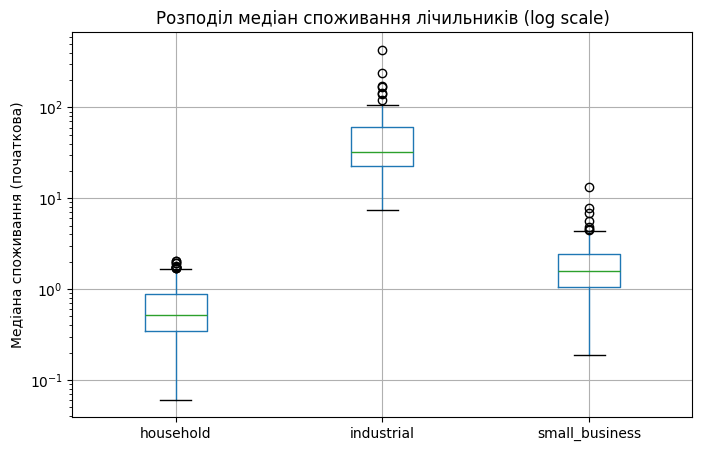

D-D: лічильників у Вт·год = 0
Найбільше відношення серед усіх: 12.19
Рядків поза межами споживання з опису: 0


In [ ]:
# TODO: D-D
# meter_median = ...  # медіана кожного лічильника
# meter_type = ...    # customer_type кожного лічильника
# type_median = ...   # медіана всіх рядків кожного customer_type
# ratio = meter_median / meter_type.map(type_median)
# Рахуємо медіани
meter_median = df.groupby("meter_id")["consumption_kwh"].median()
meter_type = df.groupby("meter_id")["customer_type"].first()
type_median = df.groupby("customer_type")["consumption_kwh"].median()

ratio = meter_median / meter_type.map(type_median)

# Графік медіан
plt.figure(figsize=(8, 5))
df.groupby(["customer_type", "meter_id"])["consumption_kwh"].median().unstack(level=0).boxplot()
plt.yscale("log")
plt.title("Розподіл медіан споживання лічильників (log scale)")
plt.ylabel("Медіана споживання (початкова)")
plt.show()

# Перевірка умови D-D (поріг > 100)
is_wh = ratio > 100
dd_count = is_wh.sum()
wh_meters = ratio[is_wh].index

print(f"D-D: лічильників у Вт·год = {dd_count}")
if dd_count > 0:
    print(f"Найбільше відношення серед решти: {ratio[~is_wh].max():.2f}")
    print(f"Найменше відношення серед Вт·год: {ratio[is_wh].min():.2f}")
    # Ділимо споживання знайдених лічильників на 1000
    df.loc[df["meter_id"].isin(wh_meters), "consumption_kwh"] /= 1000
else:
    print(f"Найбільше відношення серед усіх: {ratio.max():.2f}")

# Перевірка меж споживання після виправлення
min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1.0}
max_kwh = {"household": 10.0, "small_business": 60.0, "industrial": 1200.0}

out_of_bounds = ~df["consumption_kwh"].between(
    df["customer_type"].map(min_kwh),
    df["customer_type"].map(max_kwh)
)
print("Рядків поза межами споживання з опису:", out_of_bounds.sum())

## 7. Лічильники, що замовкли (D-A)

Пропуски не заповнюємо: те, що лічильник замовк, уже є інформацією про можливу відмову, а середнє її стерло б. Не видаляємо теж: до відмови лічильник передавав правильні дані.

Для кожного лічильника порахуйте, скільки годин минуло від його останнього `ts` до `2026-02-01 23:00`; більше 48 — замовк. Як на кроці 6, виведіть кількість замовклих, найбільшу тишу серед решти й найменшу серед замовклих (якщо замовклих немає — лише найбільшу тишу серед усіх).

Номери замовклих лічильників збережіть списком `silent`, наприклад `list(....index)`: він знадобиться в регресії.

Можуть допомогти `pd.Timestamp("2026-02-01 23:00")` і `/ pd.Timedelta(hours=1)`.

In [ ]:
# TODO: D-A
end_ts = pd.Timestamp("2026-02-01 23:00")
last_ts_per_meter = df.groupby("meter_id")["ts"].max()
hours_silent = (end_ts - last_ts_per_meter) / pd.Timedelta(hours=1)

is_silent = hours_silent > 48
da_count = is_silent.sum()
silent = list(hours_silent[is_silent].index)

print(f"D-A: замовклих лічильників = {da_count}")
if da_count > 0:
    print(f"Найбільша тиша серед решти (год): {hours_silent[~is_silent].max():.1f}")
    print(f"Найменша тиша серед замовклих (год): {hours_silent[is_silent].min():.1f}")
else:
    print(f"Найбільша тиша серед усіх (год): {hours_silent.max():.1f}")

D-A: замовклих лічильників = 48
Найбільша тиша серед решти (год): 1.0
Найменша тиша серед замовклих (год): 148.0


## 8. Завмерлі лічильники (D-B)

Завмерлі значення виглядають правдоподібно, і ні середнє, ні максимум їх не видають. Помітно лише те, що значення перестали змінюватися. Такі лічильники не видаляємо: частина їхніх годин справна.

Для кожного лічильника порахуйте частку різних значень `consumption_kwh` серед його записів; менше 0.65 — завмер. Побудуйте гістограму цієї частки по лічильниках. Як на кроці 6, виведіть кількість завмерлих, найменшу частку серед решти й найбільшу серед завмерлих (якщо завмерлих немає — лише найменшу частку серед усіх).

Номери завмерлих лічильників збережіть списком `frozen`: він знадобиться в регресії.

Можуть допомогти `nunique()`, `size()` і `plt.hist`.

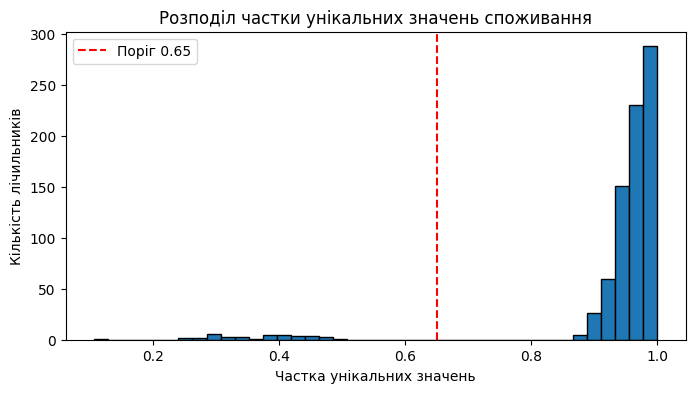

D-B: завмерлих лічильників = 40
Найменша частка серед решти: 0.8664
Найбільша частка серед завмерлих: 0.4880


In [ ]:
# TODO: D-B
# Частка унікальних значень споживання
unique_ratio = df.groupby("meter_id")["consumption_kwh"].apply(lambda s: s.nunique() / s.size)

plt.figure(figsize=(8, 4))
plt.hist(unique_ratio, bins=40, edgecolor="black")
plt.axvline(0.65, color="red", linestyle="--", label="Поріг 0.65")
plt.title("Розподіл частки унікальних значень споживання")
plt.xlabel("Частка унікальних значень")
plt.ylabel("Кількість лічильників")
plt.legend()
plt.show()

is_frozen = unique_ratio < 0.65
db_count = is_frozen.sum()
frozen = list(unique_ratio[is_frozen].index)

print(f"D-B: завмерлих лічильників = {db_count}")
if db_count > 0:
    print(f"Найменша частка серед решти: {unique_ratio[~is_frozen].min():.4f}")
    print(f"Найбільша частка серед завмерлих: {unique_ratio[is_frozen].max():.4f}")
else:
    print(f"Найменша частка серед усіх: {unique_ratio.min():.4f}")

## 9. Кореляції

Колонка, що майже копіює іншу, не додає інформації: у кластеризації вона подвоює вагу того самого фактора, а в регресії робить коефіцієнти нестабільними. Технічна колонка `record_ts` після кроку 5 теж не потрібна.

Порахуйте кореляції між числовими колонками об'єднаної таблиці. Пару з кореляцією за модулем понад 0.95 вважайте копією і лиште з неї одну колонку. Приберіть `record_ts`. Підсумкову таблицю назвіть `result`.

Можуть допомогти `select_dtypes("number").corr().abs()` і `drop(columns=...)`.

In [ ]:
# TODO: знайдіть і приберіть колонку-копію та record_ts
num_corr = df.select_dtypes("number").corr().abs()
print("Матриця кореляцій числових колонок:")
display(num_corr)

# Шукаємо дублікати (кореляція > 0.95)
copies = [(a, b) for a in num_corr for b in num_corr if a < b and num_corr.loc[a, b] > 0.95]
print("Знайдені пари колонок-копій:", copies)

# Видаляємо одну з копій (connection_year або years_connected) та record_ts
drop_cols = ["record_ts"]
if copies:
    drop_cols.append(copies[0][1])  # наприклад, years_connected

result = df.drop(columns=drop_cols)
print("Колонки, що лишилися в result:", result.columns.tolist())

Матриця кореляцій числових колонок:


,consumption_kwh,electric_heating,connection_year,years_connected
consumption_kwh,1.000000,0.090332,0.015275,0.016578
electric_heating,0.090332,1.000000,0.045976,0.045979
connection_year,0.015275,0.045976,1.000000,0.999048
years_connected,0.016578,0.045979,0.999048,1.000000


Знайдені пари колонок-копій: [('connection_year', 'years_connected')]
Колонки, що лишилися в result: ['meter_id', 'ts', 'consumption_kwh', 'customer_type', 'tariff', 'electric_heating', 'connection_year', 'district']


## 10. Самоперевірка й збереження

Якщо якась перевірка падає, поверніться до відповідного кроку.

In [ ]:
districts = ["Podil", "Solomianka", "Darnytsia", "Obolon", "Sviatoshyn"]
min_kwh = {"household": 0.01, "small_business": 0.02, "industrial": 1}
max_kwh = {"household": 10, "small_business": 60, "industrial": 1200}
corr = result.select_dtypes("number").corr().abs()
copies = [(a, b) for a in corr for b in corr if a < b and corr.loc[a, b] > 0.95]

assert not result.duplicated(["meter_id", "ts"]).any(), "лишилися повтори лічильник–година"
assert result["meter_id"].nunique() == 800, "лічильників має бути 800"
assert result["meter_id"].str.fullmatch(r"UA\d{6}").all(), "є номери не у форматі UA і 6 цифр"
assert result["customer_type"].notna().all(), "є рядки без атрибутів абонента"
assert result["district"].isin(districts).all(), "є райони, яких немає в описі"
assert result["consumption_kwh"].between(result["customer_type"].map(min_kwh), result["customer_type"].map(max_kwh)).all(), "є споживання поза межами з опису"
assert not copies, f"лишилися колонки-копії: {copies}"
assert "record_ts" not in result, "технічна колонка record_ts лишилася"

result.to_parquet("cleaned.parquet", index=False)
print("усе гаразд:", result.shape)

усе гаразд: (515359, 8)


## 11. Регресія

Регресію часто використовують, щоб передбачати певні показники. Проте лінійна регресія також показує, як кожен показник впливає на результат. Це і є регресійний аналіз.

Для прикладу подивимося, як на добове споживання домогосподарства впливають електроопалення і двозонний тариф: `y = a + b₁·x₁ + b₂·x₂`.

- `y` — середнє споживання лічильника за добу, кВт·год;
- `x₁` — `electric_heating`, `x₂` — двозонний тариф (обидва 0 або 1);
- `b₁` і `b₂` — на скільки кВт·год на добу більше споживає абонент із цим фактором за однакового іншого;
- `a` — споживання без опалення на звичайному тарифі;
- R² — яку частку розкиду споживання пояснюють обидва фактори, від 0 до 1.

Регресія тут краща за просте порівняння середніх: двозонний тариф здебільшого мають будинки з опаленням, і різниця середніх за тарифом приписала б тарифу ще й споживання на опалення.

Нормалізація не потрібна: обидва фактори мають однаковий масштаб (0 або 1), тож `b₁` і `b₂` можна порівнювати напряму, а `y` лишається в кВт·год на добу, і коефіцієнти легко пояснити. Якби фактори мали різні одиниці, наприклад площу і рік, для порівняння впливу їх спершу стандартизували б.

Лічильники з `silent` і `frozen` не беремо: у `cleaned.parquet` вони лишаються, але їхнє середнє споживання спотворене.

Код майже готовий: допишіть `homes` і запустіть.

In [ ]:
# TODO: homes — рядки result для домогосподарств без лічильників із silent і frozen
# кожну умову беріть у дужки: result[(умова 1) & ~(умова 2)]
bad_meters = set(silent) | set(frozen)
homes = result[(result["customer_type"] == "household") & (~result["meter_id"].isin(bad_meters))]

per_meter = homes.groupby("meter_id").agg(
    kwh_per_day=("consumption_kwh", "mean"),
    electric_heating=("electric_heating", "first"),
    tariff=("tariff", "first"),
)
per_meter["kwh_per_day"] *= 24
per_meter["dual_zone"] = (per_meter["tariff"] == "dual_zone").astype(int)

x = per_meter[["electric_heating", "dual_zone"]]
y = per_meter["kwh_per_day"]

model = LinearRegression().fit(x, y)
print("лічильників:", len(per_meter))
print(f"a = {model.intercept_:.2f}, b₁ (опалення) = {model.coef_[0]:.2f}, b₂ (двозонний тариф) = {model.coef_[1]:.2f}, R² = {model.score(x, y):.3f}")

лічильників: 467
a = 11.10, b₁ (опалення) = 16.28, b₂ (двозонний тариф) = 2.30, R² = 0.652
